In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')

In [3]:
X = dataset.iloc[:, [3,4]].values

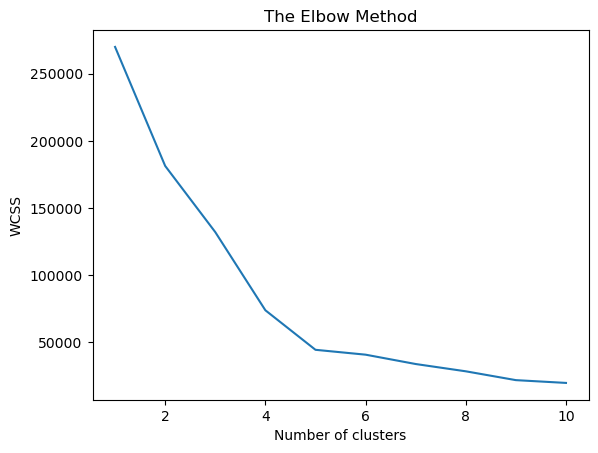

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
list1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, n_init='auto', init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    list1.append(kmeans.inertia_)
plt.plot(range(1, 11), list1)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
list1

[269981.28000000014,
 181363.59595959607,
 132087.72428243395,
 73880.64496247198,
 44448.45544793369,
 40825.16946386947,
 33859.371012691,
 28437.457328040164,
 21862.09267218289,
 19787.67055496685]

In [6]:
from sklearn.cluster import SpectralClustering

In [17]:
y_kmeans = SpectralClustering(assign_labels='discretize', n_clusters=10,
    random_state=0).fit_predict(X)

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:393: UserWarning: Exited at iteration 2000 with accuracies 
[1.81797591e-12 1.00138307e-07 2.49840700e-07 1.21437432e-06
 2.06643549e-07 1.13415472e-06 3.08588166e-07 6.73191316e-07
 4.94297715e-07 1.14856681e-06 7.02459007e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
Use iteration 1911 instead with accuracy 
8.554095617501773e-07.

  _, diffusion_map = lobpcg(
C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:393: UserWarning: Exited postprocessing with accuracies 
[7.28299831e-15 9.29475467e-08 2.30992769e-07 1.22417871e-06
 2.07515678e-07 1.14571470e-06 3.25362836e-07 7.00602258e-07
 4.91271526e-07 1.12137975e-06 3.86983012e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
  _, diffusion_map = lobpcg(


In [18]:
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 6, 0, 0, 0, 0, 0, 0, 3, 6, 3, 4, 4, 4,
       2, 1], dtype=int64)

In [19]:
supervised=dataset

In [20]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [21]:
supervised['Cluster_group']=y_kmeans

In [22]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,4
196,197,Female,45,126,28,4
197,198,Male,32,126,74,4
198,199,Male,32,137,18,2


In [23]:
supervised.to_csv("Specialcluster.csv",index=False)

In [25]:
centroids=kmeans.cluster_centers_

In [26]:
centroids

array([[ 59.64705882,  52.29411765],
       [ 80.18181818,  12.68181818],
       [ 24.58333333,   9.58333333],
       [108.18181818,  82.72727273],
       [ 28.18181818,  33.27272727],
       [ 24.95      ,  81.        ],
       [ 65.23809524,  40.14285714],
       [ 78.03571429,  81.89285714],
       [109.7       ,  22.        ],
       [ 44.32258065,  52.12903226]])

In [27]:
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 6, 0, 0, 0, 0, 0, 0, 3, 6, 3, 4, 4, 4,
       2, 1], dtype=int64)

In [28]:
supervised.columns[3]

'Annual Income (k$)'

In [29]:
supervised.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster_group'],
      dtype='object')

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


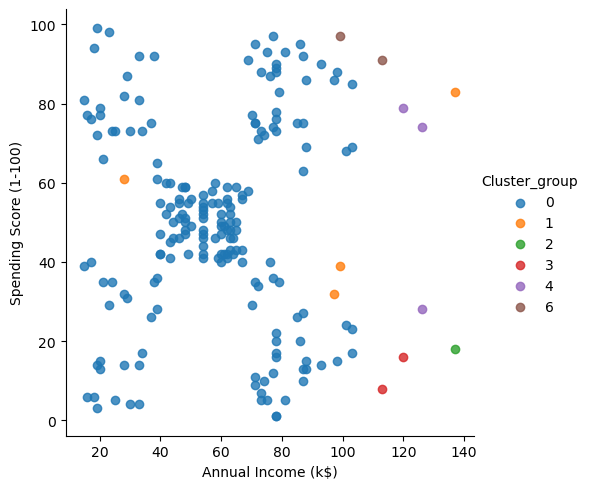

In [30]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)